# *Clase 4 - Ejercicio de regresión lineal múltiple - Ariel Tuñon*

---


# **Poroto - Serie siembra, cosecha, producción - Período 1969 a 1981**

### Serie de datos de poroto sobre la superficie sembrada, cosechada, producción y rendimiento, por provincia y departamento desde 1969. Los datos de las últimas dos campañas son provisorios.

## https://www.datos.gob.ar/dataset

**Archivo utilizado como Dataset**:   Poroto - serie siembra, cosecha,
producción.csv

---



##  Preparación y organización de datos - Adquisición, Inspección y visualización de los datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# URL modificada para obtener el archivo en formato RAW (crudo)
url_raw = "https://raw.githubusercontent.com/arieltunon74/Aprendizaje_Automatico_2026/main/Clase4/Datos/Poroto%20-%20serie%20siembra%2C%20cosecha%2C%20producci%C3%B3n.csv"

# Leer el archivo CSV
df = pd.read_csv(url_raw)
print("\nPrimeras filas del Dataset:")
display(df.head())
print("\n" * 2)



Primeras filas del Dataset:


,_id,cultivo,anio,campania,provincia,provincia_id,departamento,departamento_id,superficie_sembrada_ha,superficie_cosechada_ha,produccion_tm,rendimiento_kgxha
0,1,poroto,1969,1969/1970,Buenos Aires,6,Chacabuco,6210,10,10,12,1200
1,2,poroto,1969,1969/1970,Buenos Aires,6,Chivilcoy,6224,4,4,4,1000
2,3,poroto,1969,1969/1970,Buenos Aires,6,General Arenales,6294,1,1,1,1000
3,4,poroto,1969,1969/1970,Buenos Aires,6,Junín,6413,1,1,1,1000
4,5,poroto,1969,1969/1970,Buenos Aires,6,Mercedes,6532,64,64,81,1266


## Análisis Exploratorio de Datos (EDA):

In [ ]:
df.describe()

,_id,anio,provincia_id,departamento_id,superficie_sembrada_ha,superficie_cosechada_ha,produccion_tm,rendimiento_kgxha
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,1974.358000,52.148000,52230.965000,1549.487000,1441.043000,1363.466000,1007.427000
std,288.819436,3.393133,22.392846,22353.128258,5713.438029,5379.836037,5018.225497,352.665671
min,1.000000,1969.000000,6.000000,6210.000000,1.000000,0.000000,0.000000,0.000000
25%,250.750000,1971.000000,38.000000,38063.000000,11.000000,10.000000,10.000000,813.000000
50%,500.500000,1974.500000,54.000000,54070.000000,50.000000,50.000000,48.000000,1000.000000
75%,750.250000,1977.000000,66.000000,66147.000000,256.250000,246.250000,226.250000,1169.250000
max,1000.000000,1980.000000,90.000000,90112.000000,55000.000000,48145.000000,53109.000000,3500.000000


VISIÓN GENERAL Y ESTRUCTURA DEL DATASET Y DIAGNÓSTICO DE VALORES FALTANTES Y DUPLICADOS

In [ ]:


# Configuración visual de Seaborn
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# 1. VISIÓN GENERAL Y ESTRUCTURA DEL DATASET

print("=== DIMENSIONES DEL DATASET ===")
print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}\n")
print("\n" * 2)
print("=== TIPOS DE DATOS Y VALORES NO NULOS ===")
print(df.info())
print("\n" * 2)

# 2. DIAGNÓSTICO DE VALORES FALTANTES Y DUPLICADOS

print("=" * 65)
print("DIAGNÓSTICO DE CALIDAD DE LOS DATOS")
print("=" * 65)

# 2.1 Valores faltantes

print("\n=== VALORES FALTANTES POR COLUMNA ===")

faltantes = df.isnull().sum()
porcentaje_faltantes = (faltantes / len(df)) * 100

df_faltantes = pd.DataFrame({
    "Valores faltantes": faltantes,
    "Porcentaje (%)": porcentaje_faltantes
})

# Mostrar únicamente columnas que tienen valores faltantes
df_faltantes = df_faltantes[
    df_faltantes["Valores faltantes"] > 0
].sort_values(
    by="Porcentaje (%)",
    ascending=False
)

if df_faltantes.empty:
    print("✓ No se encontraron valores faltantes.")
else:
    print(df_faltantes.to_string(
        formatters={"Porcentaje (%)": "{:.2f}".format}
    ))

# 2.2 Filas duplicadas-

print("\n=== FILAS DUPLICADAS ===")

duplicados = df.duplicated().sum()

print(f"Filas completamente duplicadas: {duplicados}")

if duplicados == 0:
    print("✓ No se encontraron filas duplicadas.")
else:
    porcentaje_duplicados = (duplicados / len(df)) * 100

    print(f"Porcentaje de duplicados: {porcentaje_duplicados:.2f}%")

# ---------------------------------------------------------
# 2.3 Resumen general
# ---------------------------------------------------------

print("\n=== RESUMEN DEL DIAGNÓSTICO ===")

print(f"Cantidad de filas:    {df.shape[0]:,}")
print(f"Cantidad de columnas: {df.shape[1]:,}")
print(f"Total de valores faltantes: {df.isnull().sum().sum():,}")
print(f"Total de filas duplicadas:  {duplicados:,}")

print("=" * 65)

=== DIMENSIONES DEL DATASET ===
Filas: 1000 | Columnas: 12




=== TIPOS DE DATOS Y VALORES NO NULOS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   _id                      1000 non-null   int64 
 1   cultivo                  1000 non-null   object
 2   anio                     1000 non-null   int64 
 3   campania                 1000 non-null   object
 4   provincia                1000 non-null   object
 5   provincia_id             1000 non-null   int64 
 6   departamento             1000 non-null   object
 7   departamento_id          1000 non-null   int64 
 8   superficie_sembrada_ha   1000 non-null   int64 
 9   superficie_cosechada_ha  1000 non-null   int64 
 10  produccion_tm            1000 non-null   int64 
 11  rendimiento_kgxha        1000 non-null   int64 
dtypes: int64(8), object(4)
memory usage: 93.9+

# **RESUMEN ESTADÍSTICO**

In [ ]:

# ESTADÍSTICAS DESCRIPTIVAS DE VARIABLES NUMÉRICAS

print("=" * 70)
print("ESTADÍSTICAS DESCRIPTIVAS DE VARIABLES NUMÉRICAS")
print("=" * 70)

# Seleccionar únicamente variables numéricas
df_numerico = df.select_dtypes(include="number")

# Estadísticas descriptivas
estadisticas = df_numerico.describe().T

# Agregar cantidad de valores faltantes y valores únicos
estadisticas["Faltantes"] = df_numerico.isnull().sum()
estadisticas["Únicos"] = df_numerico.nunique()

# Ordenar las columnas para facilitar la lectura
estadisticas = estadisticas[
    [
        "count",
        "Faltantes",
        "Únicos",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max"
    ]
]

# Renombrar columnas
estadisticas.columns = [
    "Cantidad",
    "Faltantes",
    "Únicos",
    "Media",
    "Desv. estándar",
    "Mínimo",
    "Q1 (25%)",
    "Mediana (50%)",
    "Q3 (75%)",
    "Máximo"
]

# Mostrar resultados
display(estadisticas.round(2))
print("\n" * 2)

# Variables categóricas / texto


print("\n=== ESTADÍSTICAS DE VARIABLES CATEGÓRICAS / TEXTO ===")

df_categorico = df.select_dtypes(include=["object", "category"])

if not df_categorico.empty:
    display(df_categorico.describe().T)
else:
    print("No se encontraron variables categóricas o de texto.")


print("\n" + "=" * 70)

ESTADÍSTICAS DESCRIPTIVAS DE VARIABLES NUMÉRICAS


,Cantidad,Faltantes,Únicos,Media,Desv. estándar,Mínimo,Q1 (25%),Mediana (50%),Q3 (75%),Máximo
_id,1000.0,0,1000,500.50,288.82,1.0,250.75,500.5,750.25,1000.0
anio,1000.0,0,12,1974.36,3.39,1969.0,1971.00,1974.5,1977.00,1980.0
provincia_id,1000.0,0,16,52.15,22.39,6.0,38.00,54.0,66.00,90.0
departamento_id,1000.0,0,135,52230.96,22353.13,6210.0,38063.00,54070.0,66147.00,90112.0
superficie_sembrada_ha,1000.0,0,230,1549.49,5713.44,1.0,11.00,50.0,256.25,55000.0
superficie_cosechada_ha,1000.0,0,266,1441.04,5379.84,0.0,10.00,50.0,246.25,48145.0
produccion_tm,1000.0,0,349,1363.47,5018.23,0.0,10.00,48.0,226.25,53109.0
rendimiento_kgxha,1000.0,0,291,1007.43,352.67,0.0,813.00,1000.0,1169.25,3500.0






=== ESTADÍSTICAS DE VARIABLES CATEGÓRICAS / TEXTO ===


,count,unique,top,freq
cultivo,1000,1,poroto,1000
campania,1000,12,1969/1970,94
provincia,1000,16,Misiones,193
departamento,1000,121,Capital,31


# **Exploración de los datos**
## Histogramas para variables numéricas

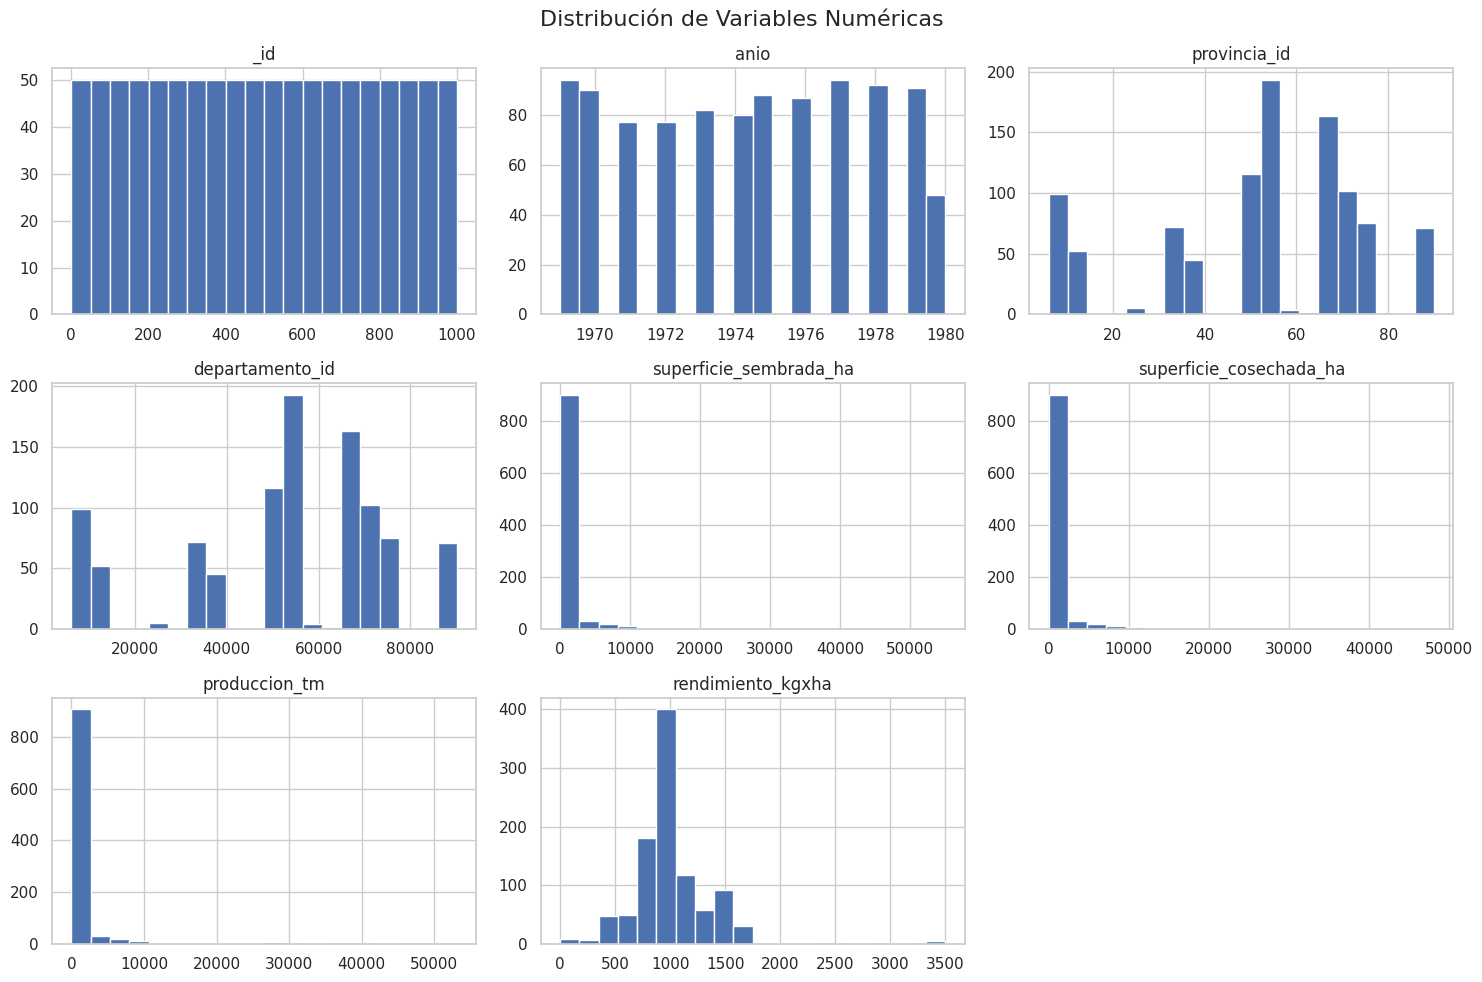

In [ ]:

# ANÁLISIS UNIVARIADO (Distribución de variables)
# Seleccionar columnas numéricas y categóricas
col_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
col_categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Histogramas para variables numéricas
if col_numericas:
    df[col_numericas].hist(bins=20, figsize=(15, 10), layout=(-1, 3))
    plt.suptitle("Distribución de Variables Numéricas", fontsize=16)
    plt.tight_layout()
    plt.show()
print("\n" * 4)


superficie_sembrada → hectáreas

superficie_cosechada → hectáreas

rendimiento → kg/ha

produccion → toneladas


# **DIAGRAMAS DE CAJA (BOXPLOTS) PARA DETECTAR OUTLIERS / ATÍPICOS**

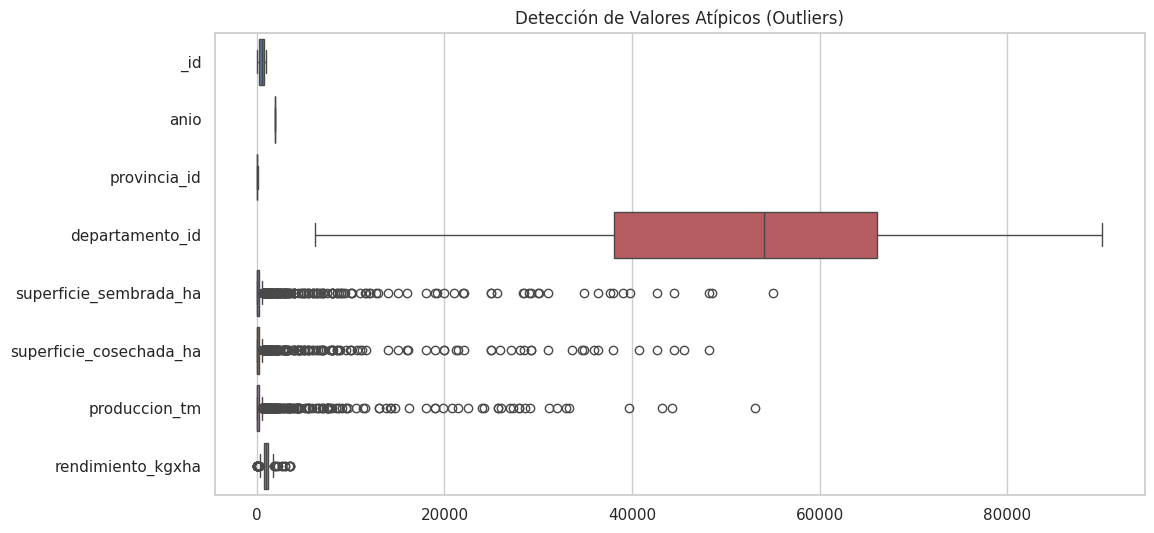

In [ ]:
# Diagramas de caja (Boxplots) para detectar Outliers/Atípicos
if col_numericas:
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df[col_numericas], orient="h")
    plt.title("Detección de Valores Atípicos (Outliers)")
    plt.show()


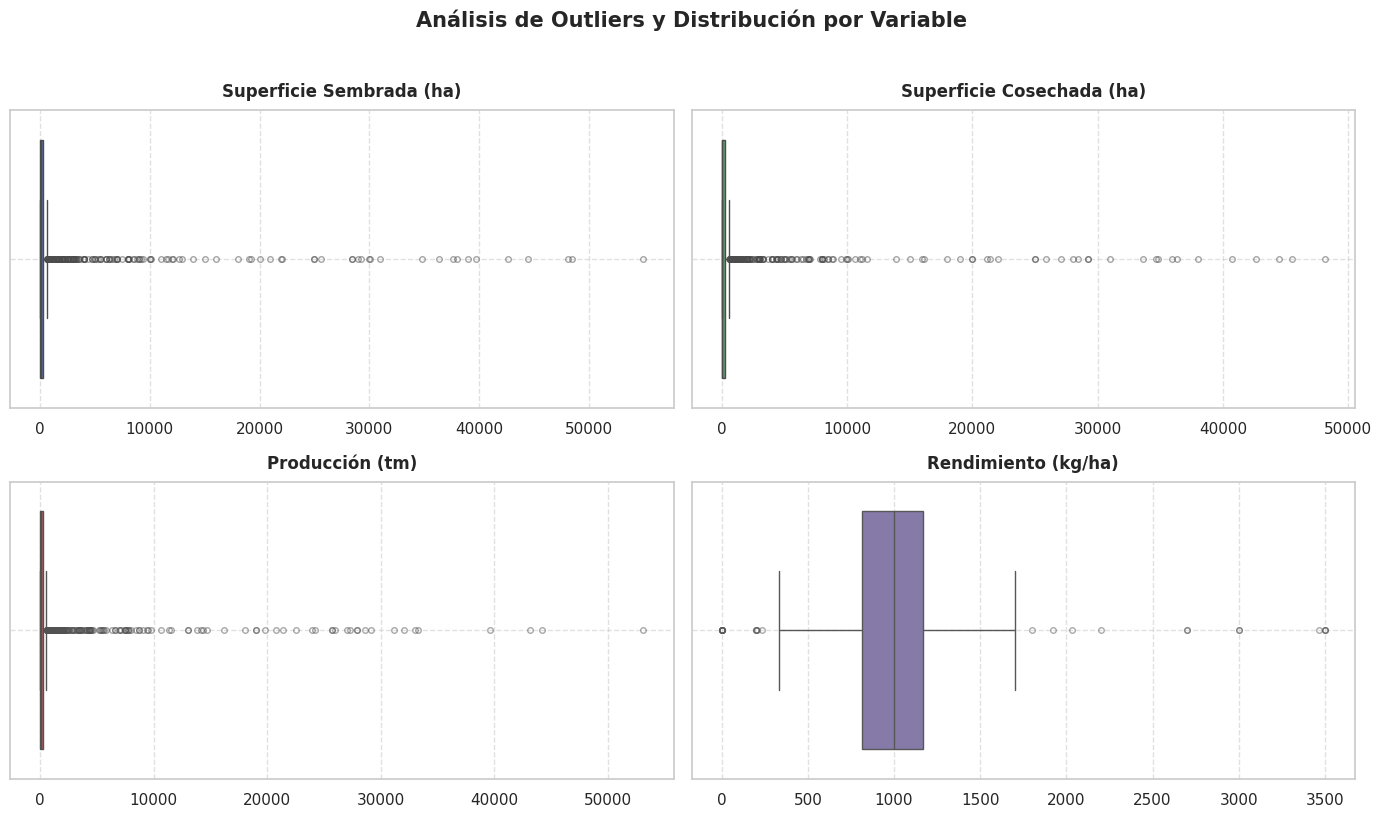

In [ ]:


# 1. Definir las variables métricas reales que queremos analizar
variables_interes = [
    'superficie_sembrada_ha',
    'superficie_cosechada_ha',
    'produccion_tm',
    'rendimiento_kgxha'
]

# 2. Definir nombres limpios para las etiquetas
titulos = [
    'Superficie Sembrada (ha)',
    'Superficie Cosechada (ha)',
    'Producción (tm)',
    'Rendimiento (kg/ha)'
]

# 3. Configurar la figura con 4 subgráficos (2 filas, 2 columnas)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8))
axes = axes.flatten()  # Aplanar la matriz de ejes para iterar fácilmente

# Paleta de colores atractiva
colores = ['#4c72b0', '#55a868', '#c44e52', '#8172b0']

# 4. Generar un boxplot independiente para cada variable
for i, col in enumerate(variables_interes):
    sns.boxplot(
        data=df,
        x=col,
        ax=axes[i],
        color=colores[i],
        flierprops={'marker': 'o', 'markersize': 4, 'alpha': 0.5} # Estilo de los outliers
    )

    axes[i].set_title(titulos[i], fontsize=12, fontweight='bold', pad=10)
    axes[i].set_xlabel('')  # Quitar etiqueta redundante del eje X
    axes[i].grid(True, linestyle='--', alpha=0.6)

# 5. Ajustar espacio entre gráficos y mostrar
plt.suptitle('Análisis de Outliers y Distribución por Variable', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Escalas independientes: Cada gráfico aprovecha el 100% del ancho para su propio rango de valores, lo que permite observar la caja (Q1, Mediana, Q3) claramente en cada variable.

Transparencia en outliers: Los puntos atípicos se grafican con cierta transparencia (alpha=0.5) para ver dónde se acumula mayor densidad de datos extremos.

Títulos claros: Reemplaza los nombres de columnas del código (_id, superficie_sembrada_ha) por etiquetas legibles y formateadas.

# **DETECCIÓN DE OUTLIERS MEDIANTE IQR - OBSERVACIONES**

In [ ]:
# ---------------------------------------------------------
# DETECCIÓN DE OUTLIERS MEDIANTE IQR
# ---------------------------------------------------------

import pandas as pd
print("\n=== DETECCIÓN DE OUTLIERS MEDIANTE EL MÉTODO DEL RANGO INTERCUARTÍLICO (IQR) ===")
# Seleccionar variables numéricas
df_numerico = df.select_dtypes(include="number")

resultados_outliers = []

for columna in df_numerico.columns:

    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)

    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    cantidad = (
        (df[columna] < limite_inferior) |
        (df[columna] > limite_superior)
    ).sum()

    porcentaje = cantidad / len(df) * 100

    resultados_outliers.append({
        "Variable": columna,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Límite inferior": limite_inferior,
        "Límite superior": limite_superior,
        "Outliers": cantidad,
        "Porcentaje (%)": porcentaje
    })

df_outliers = pd.DataFrame(resultados_outliers)

display(df_outliers.round(2))


=== DETECCIÓN DE OUTLIERS MEDIANTE EL MÉTODO DEL RANGO INTERCUARTÍLICO (IQR) ===


,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Outliers,Porcentaje (%)
0,_id,250.75,750.25,499.50,-498.50,1499.50,0,0.0
1,anio,1971.00,1977.00,6.00,1962.00,1986.00,0,0.0
2,provincia_id,38.00,66.00,28.00,-4.00,108.00,0,0.0
3,departamento_id,38063.00,66147.00,28084.00,-4063.00,108273.00,0,0.0
4,superficie_sembrada_ha,11.00,256.25,245.25,-356.88,624.12,189,18.9
5,superficie_cosechada_ha,10.00,246.25,236.25,-344.38,600.62,186,18.6
6,produccion_tm,10.00,226.25,216.25,-314.38,550.62,191,19.1
7,rendimiento_kgxha,813.00,1169.25,356.25,278.62,1703.62,25,2.5


### En agronomía y economía, estos outliers no suelen ser errores, sino información real sobre regiones hiperproductivas o grandes establecimientos. Son outliers reales del negocio (no errores) superiores a $624.12\text{ ha}$ de siembra o $550.62\text{ tm}$ de producción.

### Conclusión práctica: No corresponden a errores de medición o carga, sino a outliers de dominio (verdaderos valores atípicos del negocio). Eliminarlos significaría perder las zonas agrícolas más productivas del país.

# **ANÁLISIS BIVARIADO Y CORRELACIONES**
## Matriz de Correlación (solo numéricas) - Aplicado a todo el Dataset.


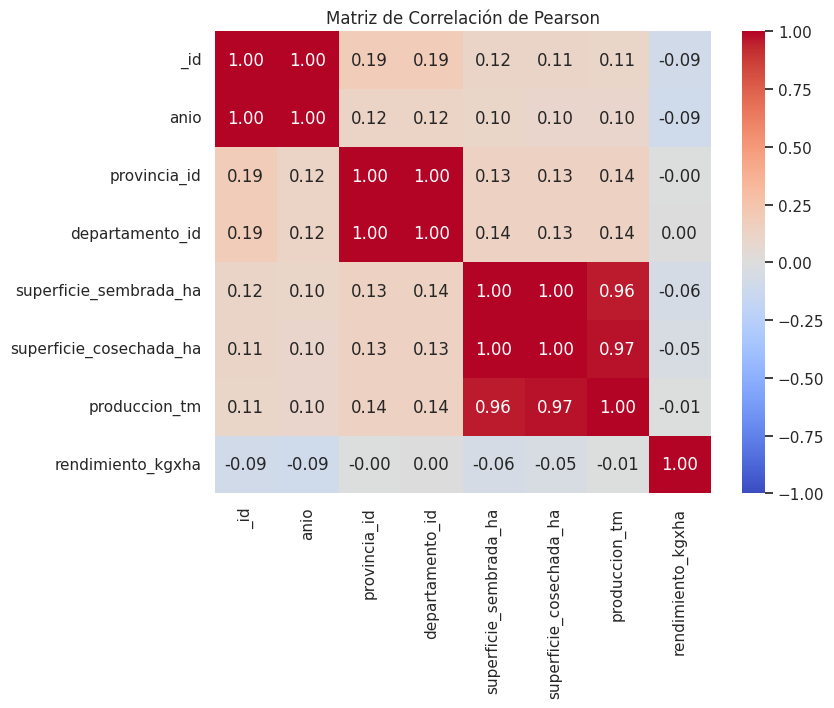

In [ ]:

# ANÁLISIS BIVARIADO Y CORRELACIONES
# Matriz de Correlación (solo numéricas)
if len(col_numericas) > 1:
    plt.figure(figsize=(8, 6))
    matriz_corr = df[col_numericas].corr()
    sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
    plt.title("Matriz de Correlación de Pearson")
    plt.show()
    print("\n" * 4)


# **TRATAMIENTO DEL DATASET** - Modelado de datos

# **Inspección, limpieza e imputación**
## Inspección antes de transformar:

In [ ]:
df.head()


,_id,cultivo,anio,campania,provincia,provincia_id,departamento,departamento_id,superficie_sembrada_ha,superficie_cosechada_ha,produccion_tm,rendimiento_kgxha
0,1,poroto,1969,1969/1970,Buenos Aires,6,Chacabuco,6210,10,10,12,1200
1,2,poroto,1969,1969/1970,Buenos Aires,6,Chivilcoy,6224,4,4,4,1000
2,3,poroto,1969,1969/1970,Buenos Aires,6,General Arenales,6294,1,1,1,1000
3,4,poroto,1969,1969/1970,Buenos Aires,6,Junín,6413,1,1,1,1000
4,5,poroto,1969,1969/1970,Buenos Aires,6,Mercedes,6532,64,64,81,1266


In [ ]:
# ---------------------------------------------------------
# DIAGNÓSTICO DE VALORES FALTANTES
# ---------------------------------------------------------

print("=" * 60)
print("DIAGNÓSTICO DE VALORES FALTANTES")
print("=" * 60)

faltantes = df.isnull().sum()
porcentaje_faltantes = (faltantes / len(df)) * 100

df_faltantes = pd.DataFrame({
    "Valores faltantes": faltantes,
    "Porcentaje (%)": porcentaje_faltantes
})

# Mostrar todas las columnas
display(df_faltantes.round(2))

# Resumen
total_faltantes = df.isnull().sum().sum()

print(f"\nTotal de filas:              {len(df):,}")
print(f"Total de valores faltantes:  {total_faltantes:,}")

if total_faltantes == 0:
    print("\n✓ No se encontraron valores faltantes.")
else:
    print("\n⚠ Se encontraron valores faltantes.")


DIAGNÓSTICO DE VALORES FALTANTES


,Valores faltantes,Porcentaje (%)
_id,0,0.0
cultivo,0,0.0
anio,0,0.0
campania,0,0.0
provincia,0,0.0
provincia_id,0,0.0
departamento,0,0.0
departamento_id,0,0.0
superficie_sembrada_ha,0,0.0
superficie_cosechada_ha,0,0.0



Total de filas:              1,000
Total de valores faltantes:  0

✓ No se encontraron valores faltantes.


## Sin datos faltantes, no necesita imputar datos.
## El dataset no necesita eliminar filas duplicadas

## **Técnica de preprocesamiento One-hot encoding para las variables de la columna  provincias**

In [ ]:
df_encoded = pd.get_dummies(
    df,
    columns=["provincia"],
    drop_first=True,
    dtype=int
)

display(df_encoded.head())

,_id,cultivo,anio,campania,provincia_id,departamento,departamento_id,superficie_sembrada_ha,superficie_cosechada_ha,produccion_tm,...,provincia_Jujuy,provincia_Mendoza,provincia_Misiones,provincia_Neuquén,provincia_Río Negro,provincia_Salta,provincia_San Juan,provincia_San Luis,provincia_Santiago del Estero,provincia_Tucumán
0,1,poroto,1969,1969/1970,6,Chacabuco,6210,10,10,12,...,0,0,0,0,0,0,0,0,0,0
1,2,poroto,1969,1969/1970,6,Chivilcoy,6224,4,4,4,...,0,0,0,0,0,0,0,0,0,0
2,3,poroto,1969,1969/1970,6,General Arenales,6294,1,1,1,...,0,0,0,0,0,0,0,0,0,0
3,4,poroto,1969,1969/1970,6,Junín,6413,1,1,1,...,0,0,0,0,0,0,0,0,0,0
4,5,poroto,1969,1969/1970,6,Mercedes,6532,64,64,81,...,0,0,0,0,0,0,0,0,0,0


# **IMPLEMENTACIÓN DEL MODELO DE REGRESIÓN LINEAL MÚLTIPLE**

---





Modelo de regresión lineal múltiple considerando la variable objetivo **produccion_tm** con las variables predictoras **superficie_cosechada_ha**, **superficie_sembrada_ha **y **rendimiento_kgxh**a.

El R² moderado sugiere que hay otras variables no incluidas en el modelo que podrían explicar una mayor parte de la variabilidad del rendimiento.

                            OLS Regression Results                            
Dep. Variable:          produccion_tm   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.958
Method:                 Least Squares   F-statistic:                     7555.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:22:39   Log-Likelihood:                -8355.4
No. Observations:                1000   AIC:                         1.672e+04
Df Residuals:                     996   BIC:                         1.674e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                    -

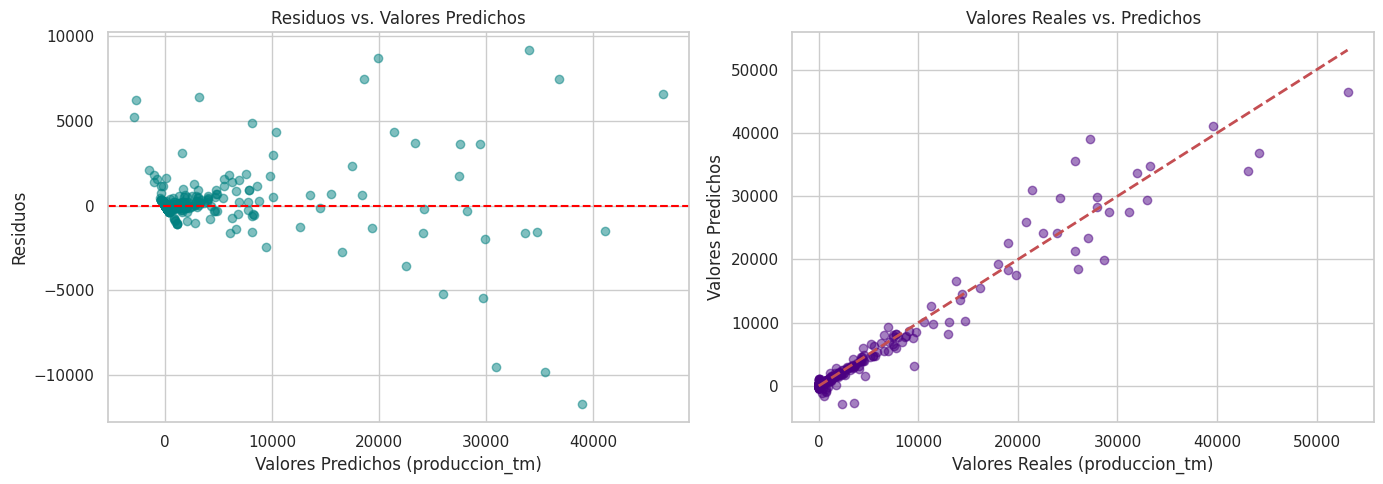

In [ ]:


import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración gráfica de Seaborn
sns.set_theme(style="whitegrid")

# Limpieza de datos (eliminar valores nulos en las variables del modelo)
variables_modelo = ['superficie_sembrada_ha', 'superficie_cosechada_ha', 'rendimiento_kgxha', 'produccion_tm']
data = df.dropna(subset=variables_modelo)

# Definición de variables
X = data[['superficie_sembrada_ha', 'superficie_cosechada_ha', 'rendimiento_kgxha']]
y = data['produccion_tm']

# Añadir intersección / constante
X_const = sm.add_constant(X)

# Ajuste del modelo OLS (Mínimos Cuadrados Ordinarios)
modelo = sm.OLS(y, X_const).fit()

# Imprimir el resumen estadístico
print(modelo.summary())

# 6. Evaluación de Multicolinealidad (VIF)
vif_df = pd.DataFrame()
vif_df["Variable"] = X_const.columns
vif_df["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
print("\n--- Factor de Inflación de la Varianza (VIF) ---")
print(vif_df)
print("\n" * 2)
# 7. Visualización del Diagnóstico de Residuos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
print("\n" * 2)
# Gráfico 1: Residuos vs Valores Predichos
axes[0].scatter(modelo.fittedvalues, modelo.resid, alpha=0.5, color='teal')
axes[0].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('Valores Predichos (produccion_tm)')
axes[0].set_ylabel('Residuos')
axes[0].set_title('Residuos vs. Valores Predichos')

# Gráfico 2: Valores Reales vs Predichos
axes[1].scatter(y, modelo.fittedvalues, alpha=0.5, color='indigo')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[1].set_xlabel('Valores Reales (produccion_tm)')
axes[1].set_ylabel('Valores Predichos')
axes[1].set_title('Valores Reales vs. Predichos')

plt.tight_layout()
plt.show()

# **En el primer modelo se detecta multicolinealidad entre algunas variables predictoras !**

### Se detectó multicolinealidad entre las variables predictoras, pero implementando el modelo Ridge ha logrado producir coeficientes estables y un rendimiento predictivo más razonable tomando como variable objetivo el **rendimiento_kgxha**, manejando la multicolinealidad de manera efectiva.

## Regresión Ridge para mitigar la multicolinealidad

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar las características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ajustar el modelo de Regresión Ridge
# Se puede experimentar con diferentes valores de alpha (parámetro de regularización)
ridge_model = Ridge(alpha=1.0) # alpha=1.0 es el valor por defecto
ridge_model.fit(X_train_scaled, y_train)

# Evaluar el modelo
y_train_pred = ridge_model.predict(X_train_scaled)
y_test_pred = ridge_model.predict(X_test_scaled)

r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print(f"R-squared en el conjunto de entrenamiento (Ridge): {r2_train:.3f}")
print(f"R-squared en el conjunto de prueba (Ridge): {r2_test:.3f}")

print("\nCoeficientes del modelo Ridge:")
coeficientes_ridge = pd.DataFrame({'Variable': X.columns, 'Coeficiente': ridge_model.coef_})
display(coeficientes_ridge)

R-squared en el conjunto de entrenamiento (Ridge): 0.952
R-squared en el conjunto de prueba (Ridge): 0.961

Coeficientes del modelo Ridge:


,Variable,Coeficiente
0,superficie_sembrada_ha,-3179.096678
1,superficie_cosechada_ha,7519.539151
2,rendimiento_kgxha,144.235702


### El modelo Ridge ha sido ajustado. Los valores de R-squared nos dan una idea de la capacidad predictiva del modelo en los datos de entrenamiento y prueba.


# Visualización de la Importancia de las Variables en el Modelo Ridge

/tmp/ipykernel_2181/4144970242.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coeficiente', y='Variable', data=coeficientes_ridge_sorted, palette='viridis')


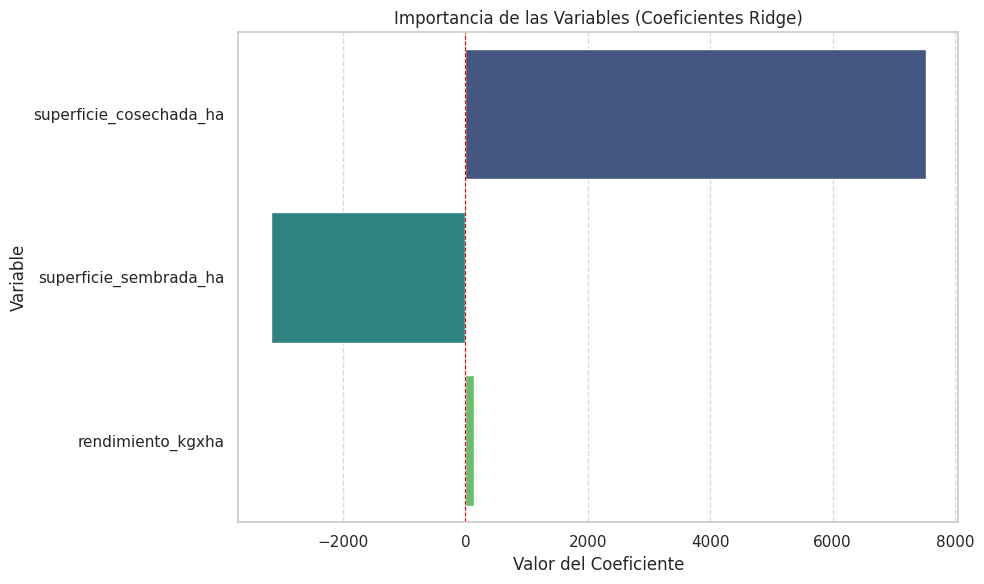

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ordenar los coeficientes por su valor absoluto para mejor visualización
coeficientes_ridge_sorted = coeficientes_ridge.reindex(coeficientes_ridge['Coeficiente'].abs().sort_values(ascending=False).index)

plt.figure(figsize=(10, 6))
sns.barplot(x='Coeficiente', y='Variable', data=coeficientes_ridge_sorted, palette='viridis')
plt.title('Importancia de las Variables (Coeficientes Ridge)')
plt.xlabel('Valor del Coeficiente')
plt.ylabel('Variable')
plt.axvline(x=0, color='red', linestyle='--', linewidth=0.8) # Añadir una línea en cero para referencia
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Este gráfico de barras muestra los coeficientes de cada variable en el modelo Ridge, ordenados por su magnitud absoluta. Los coeficientes más largos (positivos o negativos) indican una mayor influencia de la variable en la predicción de la producción. Como se mencionó anteriormente, la interpretación de estos coeficientes debe hacerse considerando que las variables fueron escaladas antes de ajustar el modelo Ridge.

# **Comprobar correlación entre predictoras**

# **Predicción del Rendimiento Agrícola (rendimiento_kgxha)**


RESUMEN DEL MODELO RIDGE PARA RENDIMIENTO_KGXHA

Coeficientes del modelo Ridge (sobre datos escalados):


,Variable,Coeficiente
0,anio,-36.703964
1,provincia_Catamarca,-82.098374
2,provincia_Chaco,-21.138204
3,provincia_Chubut,-60.354073
4,provincia_Córdoba,-106.946889
5,provincia_Formosa,-59.277824
6,provincia_Jujuy,-71.247111
7,provincia_Mendoza,-55.106964
8,provincia_Misiones,-182.455927
9,provincia_Neuquén,-5.106055



MÉTRICAS DE EVALUACIÓN EN CONJUNTO DE PRUEBA (TEST) - REGRESIÓN RIDGE
R² (Coeficiente de Determinación): 0.2943
MAE (Error Absoluto Medio): 188.25 kg/ha
RMSE (Raíz del Error Cuadrático Medio): 288.02 kg/ha





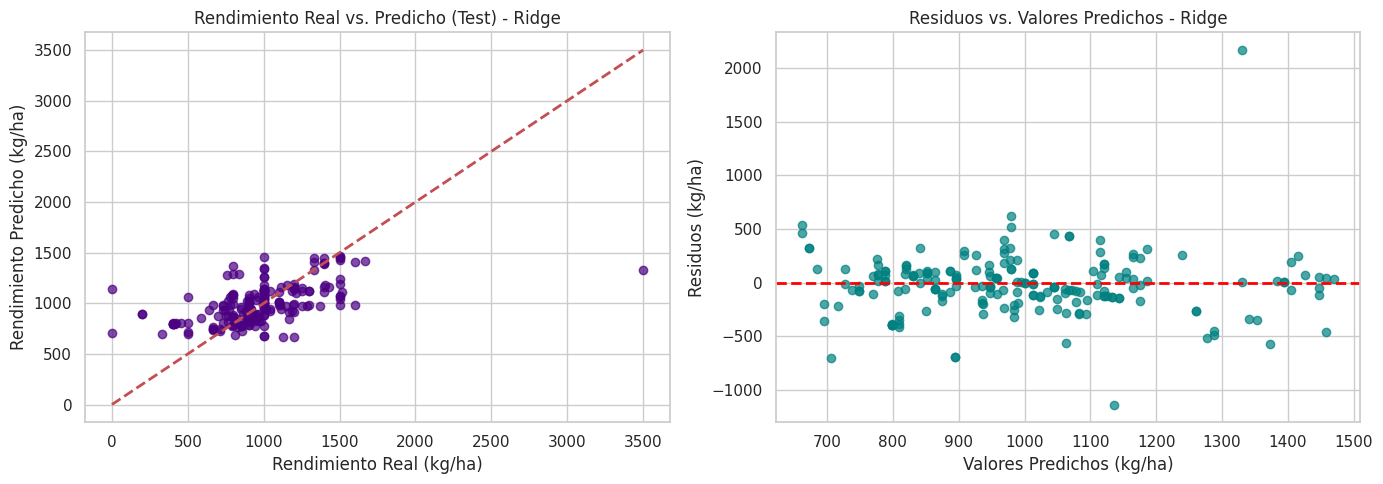

In [ ]:
# ==============================================================================
# PREDICCIÓN DEL RENDIMIENTO AGRÍCOLA (rendimiento_kgxha) - REGRESIÓN RIDGE
# ==============================================================================

# 1. Librerías
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.linear_model import Ridge # Importar modelo Ridge
from sklearn.preprocessing import StandardScaler # Importar escalador

sns.set_theme(style="whitegrid")

# 2. Cargar datos
# df = pd.read_csv('Poroto - serie siembra, cosecha, producción.csv') # Already loaded in a previous cell

# 3. Preprocesamiento e Ingeniería de Características
data = df.dropna(subset=['superficie_sembrada_ha', 'superficie_cosechada_ha', 'rendimiento_kgxha', 'provincia', 'anio']).copy()

# Generación de variables de pérdida de cultivo
data['hectareas_perdidas'] = data['superficie_sembrada_ha'] - data['superficie_cosechada_ha']
data['pct_perdida'] = np.where(
    data['superficie_sembrada_ha'] > 0,
    (data['hectareas_perdidas'] / data['superficie_sembrada_ha']) * 100,
    0
)

# Codificación categórica One-Hot Encoding para las provincias
data_encoded = pd.get_dummies(data, columns=['provincia'], drop_first=True, dtype=float)

# FIX: Ensure 'provincia_id' is removed from data_encoded if it exists,
# as its information is redundant with one-hot encoded province columns
if 'provincia_id' in data_encoded.columns:
    data_encoded = data_encoded.drop(columns=['provincia_id'])

# 4. Definición de predictores (X) y variable objetivo (y)
provincia_cols = [col for col in data_encoded.columns if col.startswith('provincia_')]
# Se incluyen todas las provincias y se eliminan las variables de pérdida que causaban multicolinealidad con el intercepto y entre ellas.
# La multicolinealidad entre las provincias la manejará Ridge.
feature_cols = ['anio'] + provincia_cols # Se usan todas las variables de provincia dummy para que Ridge las penalice

X = data_encoded[feature_cols]
y = data_encoded['rendimiento_kgxha']

# 5. División Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Escalar las características para Ridge Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertir las matrices escaladas de nuevo a DataFrame para mantener los nombres de las columnas
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Añadir constante/intercepto a los datos escalados
X_train_const = sm.add_constant(X_train_scaled_df) # Necesario para statsmodels OLS-like summary
X_test_const = sm.add_constant(X_test_scaled_df)

# 7. Entrenamiento del Modelo de Regresión Ridge
# Se puede experimentar con diferentes valores de alpha (parámetro de regularización)
ridge_model_rendimiento = Ridge(alpha=1.0, random_state=42) # alpha=1.0 es un valor por defecto razonable
ridge_model_rendimiento.fit(X_train_scaled, y_train)

# Generar un resumen estilo OLS para Ridge (opcional, para ver p-valores, pero los coeficientes serán para datos escalados)
# Para un resumen completo de statsmodels se podría ajustar OLS con los datos escalados, pero la interpretación
# de coeficientes sería sobre las variables escaladas. La fuerza de Ridge es manejar la multicolinealidad.
# Aquí se usarán las métricas de sklearn.

print("\n==================================================")
print("RESUMEN DEL MODELO RIDGE PARA RENDIMIENTO_KGXHA")
print("==================================================")

print("\nCoeficientes del modelo Ridge (sobre datos escalados):")
coeficientes_ridge_rendimiento = pd.DataFrame({'Variable': X.columns, 'Coeficiente': ridge_model_rendimiento.coef_})
display(coeficientes_ridge_rendimiento)

# 8. Evaluación en el Conjunto de Prueba
y_pred = ridge_model_rendimiento.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n" + "="*50)
print("MÉTRICAS DE EVALUACIÓN EN CONJUNTO DE PRUEBA (TEST) - REGRESIÓN RIDGE")
print("="*50)
print(f"R² (Coeficiente de Determinación): {r2:.4f}")
print(f"MAE (Error Absoluto Medio): {mae:.2f} kg/ha")
print(f"RMSE (Raíz del Error Cuadrático Medio): {rmse:.2f} kg/ha")
print("\n" * 2)
# 9. Gráficos de Diagnóstico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Real vs Predicho
axes[0].scatter(y_test, y_pred, alpha=0.7, color='indigo')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Rendimiento Real (kg/ha)')
axes[0].set_ylabel('Rendimiento Predicho (kg/ha)')
axes[0].set_title('Rendimiento Real vs. Predicho (Test) - Ridge')

# Residuos
residuos = y_test - y_pred
axes[1].scatter(y_pred, residuos, alpha=0.7, color='teal')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_xlabel('Valores Predichos (kg/ha)')
axes[1].set_ylabel('Residuos (kg/ha)')
axes[1].set_title('Residuos vs. Valores Predichos - Ridge')

plt.tight_layout()
plt.show()

# **R² = 0.2943**

## El modelo Ridge explica aproximadamente el 29,4% de las variaciones del rendimiento en kg/ha, mientras que aproximadamente el 70,6% restante queda sin explicar por las variables utilizadas.

# ***"El modelo presenta una capacidad predictiva limitada/moderada."***

### Faltan variables que expliquen mejor el rendimiento.

## El MAE fue de 188,25 kg/ha, mientras que el RMSE alcanzó 288,02 kg/ha. Estos resultados indican que el modelo presenta una capacidad predictiva limitada y que sería conveniente incorporar otras variables relevantes para mejorar las predicciones.

# **GRÁFICOS DEL MODELO DE RENDIMIENTO**

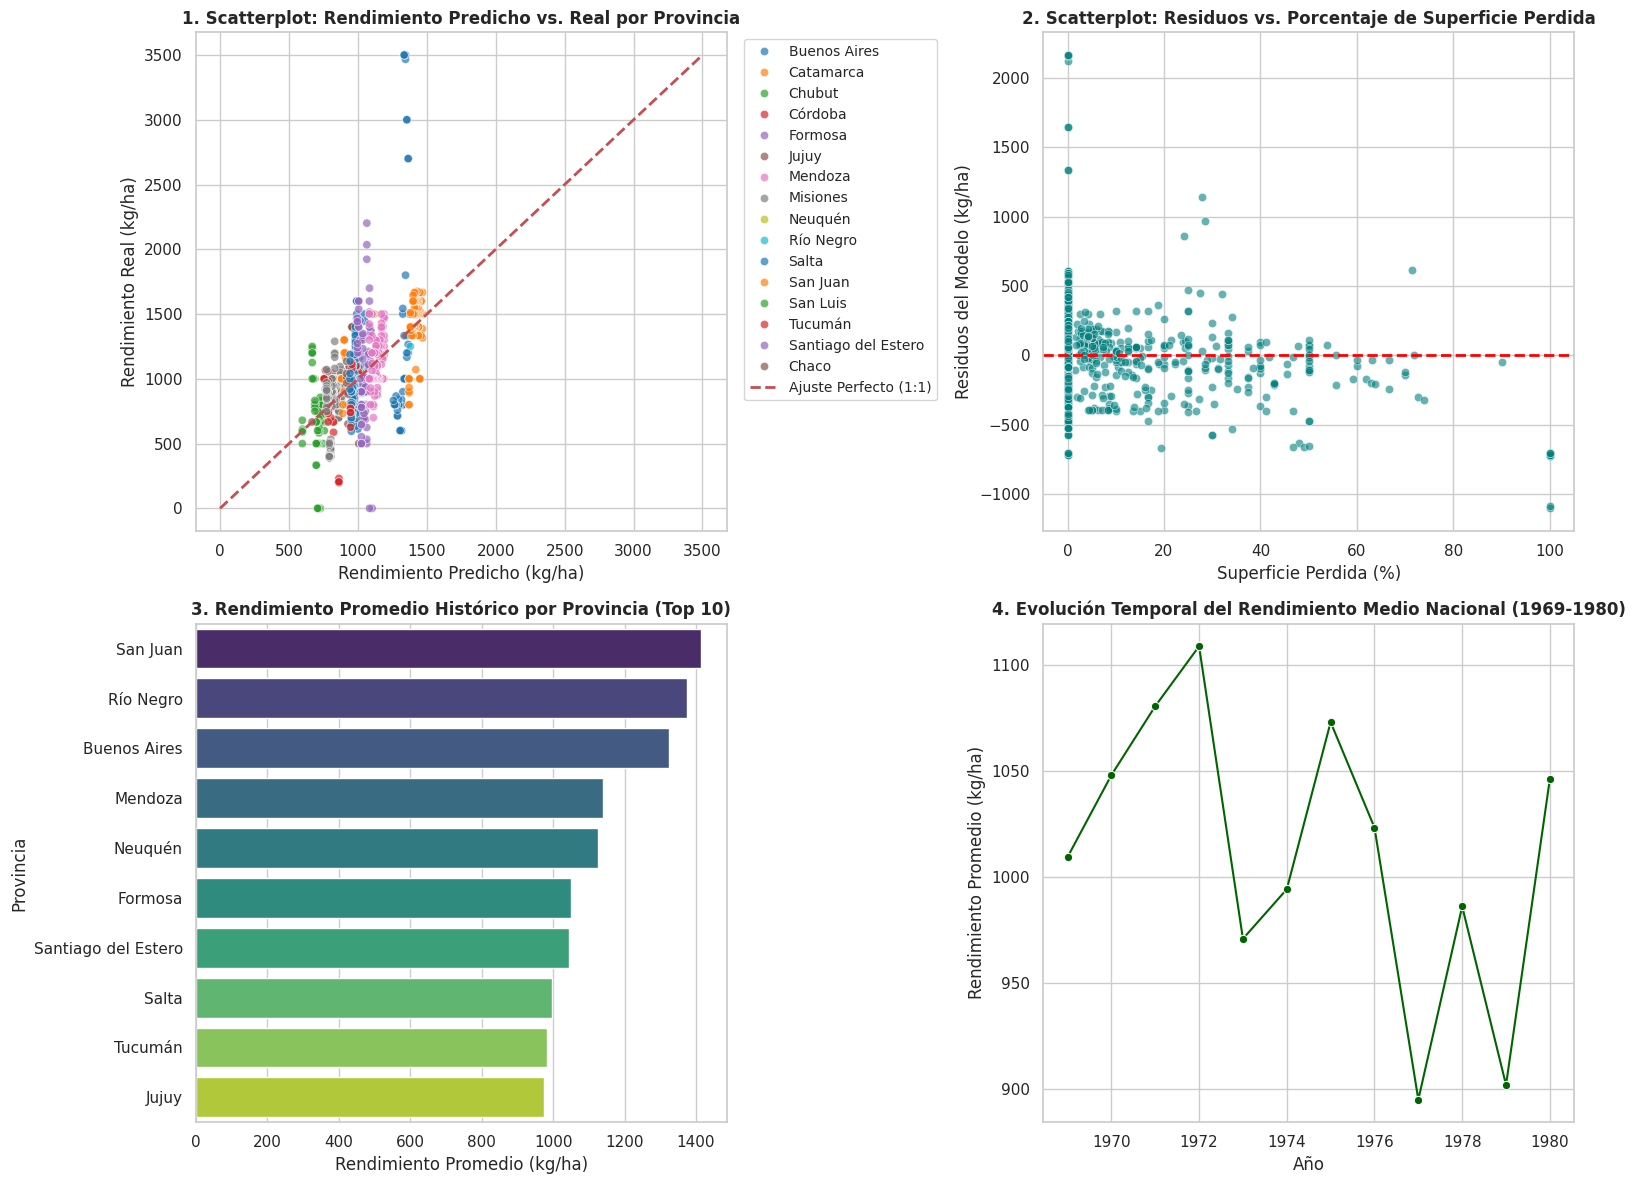

In [ ]:
# ==============================================================================
# CÓDIGO PARA GENERAR EL PANEL DE GRÁFICOS DEL MODELO DE RENDIMIENTO
# ==============================================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración del estilo gráfico
sns.set_theme(style="whitegrid")

# 1. Cargar el dataset
# URL modificada para obtener el archivo en formato RAW (crudo)
url_raw = "https://raw.githubusercontent.com/arieltunon74/Aprendizaje_Automatico_2026/main/Clase4/Datos/Poroto%20-%20serie%20siembra%2C%20cosecha%2C%20producci%C3%B3n.csv"
df = pd.read_csv(url_raw) # Dataset already loaded in previous cells

# 2. Preprocesamiento e Ingeniería de Características
data = df.dropna(subset=['superficie_sembrada_ha', 'superficie_cosechada_ha', 'rendimiento_kgxha', 'provincia', 'anio']).copy()

# Variables de pérdida de superficie
data['hectareas_perdidas'] = data['superficie_sembrada_ha'] - data['superficie_cosechada_ha']
data['pct_perdida'] = np.where(
    data['superficie_sembrada_ha'] > 0,
    (data['hectareas_perdidas'] / data['superficie_sembrada_ha']) * 100,
    0
)

# Codificación categórica (One-Hot Encoding para provincias)
data_encoded = pd.get_dummies(data, columns=['provincia'], drop_first=True, dtype=float)

# FIX: Ensure 'provincia_id' is removed from data_encoded if it exists,
# as its information is redundant with one-hot encoded province columns
if 'provincia_id' in data_encoded.columns:
    data_encoded = data_encoded.drop(columns=['provincia_id'])

# 3. Entrenamiento del Modelo de Regresión Lineal OLS
provincia_cols = [col for col in data_encoded.columns if col.startswith('provincia_')]

feature_cols = ['anio'] + provincia_cols

X = data_encoded[feature_cols]
y = data_encoded['rendimiento_kgxha']

X_const = sm.add_constant(X)
modelo = sm.OLS(y, X_const).fit()

# Obtener predicciones y residuos del modelo
data['predicho'] = modelo.predict(X_const)
data['residuos'] = modelo.resid

# 4. Generación de la Figura con los 4 Gráficos
fig = plt.figure(figsize=(16, 12))

# ------------------------------------------------------------------------------
# Gráfico 1: Scatterplot - Rendimiento Predicho vs. Real por Provincia
# ------------------------------------------------------------------------------
ax1 = fig.add_subplot(2, 2, 1)
sns.scatterplot(
    data=data,
    x='predicho',
    y='rendimiento_kgxha',
    hue='provincia',
    palette='tab10',
    alpha=0.7,
    ax=ax1
)
ax1.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Ajuste Perfecto (1:1)')
ax1.set_title('1. Scatterplot: Rendimiento Predicho vs. Real por Provincia', fontsize=12, fontweight='bold')
ax1.set_xlabel('Rendimiento Predicho (kg/ha)')
ax1.set_ylabel('Rendimiento Real (kg/ha)')
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize='small')

# ------------------------------------------------------------------------------
# Gráfico 2: Scatterplot - Residuos vs. Porcentaje de Superficie Perdida
# ------------------------------------------------------------------------------
ax2 = fig.add_subplot(2, 2, 2)
sns.scatterplot(
    data=data,
    x='pct_perdida',
    y='residuos',
    color='teal',
    alpha=0.6,
    ax=ax2
)
ax2.axhline(0, color='red', linestyle='--', lw=2)
ax2.set_title('2. Scatterplot: Residuos vs. Porcentaje de Superficie Perdida', fontsize=12, fontweight='bold')
ax2.set_xlabel('Superficie Perdida (%)')
ax2.set_ylabel('Residuos del Modelo (kg/ha)')

# ------------------------------------------------------------------------------
# Gráfico 3: Barplot - Rendimiento Promedio por Provincia (Top 10)
# ------------------------------------------------------------------------------
ax3 = fig.add_subplot(2, 2, 3)
top_provs = data.groupby('provincia')['rendimiento_kgxha'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_provs.values, y=top_provs.index, hue=top_provs.index, palette='viridis', ax=ax3, legend=False) # Add hue and legend=False to address FutureWarning
ax3.set_title('3. Rendimiento Promedio Histórico por Provincia (Top 10)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Rendimiento Promedio (kg/ha)')
ax3.set_ylabel('Provincia')

# ------------------------------------------------------------------------------
# Gráfico 4: Lineplot - Evolución Temporal del Rendimiento Medio Nacional
# ------------------------------------------------------------------------------
ax4 = fig.add_subplot(2, 2, 4)
sns.lineplot(
    data=data,
    x='anio',
    y='rendimiento_kgxha',
    errorbar=None,
    marker='o',
    color='darkgreen',
    ax=ax4
)
anio_min = data['anio'].min()
anio_max = data['anio'].max()

ax4.set_title(f'4. Evolución Temporal del Rendimiento Medio Nacional ({anio_min}-{anio_max})', fontsize=12, fontweight='bold')
# ax4.set_title('4. Evolución Temporal del Rendimiento Medio Nacional (1969-1980)', fontsize=12, fontweight='bold')
ax4.set_xlabel('Año')
ax4.set_ylabel('Rendimiento Promedio (kg/ha)')

# Ajuste de diseño y despliegue
plt.tight_layout()
plt.show()

# Evolución Temporal del Rendimiento Medio Nacional de la siembra de porotos en Argentina durante un período analizado (1969-1981).

### A lo largo de esos doce años, la productividad mostró un comportamiento marcadamente inestable, alternando picos de alto rendimiento —como el máximo registrado en 1972 (superando los 1100 kg/ha)— con caídas drásticas, alcanzando sus puntos más bajos en 1977 y 1979 (alrededor de los 900 kg/ha).